Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        

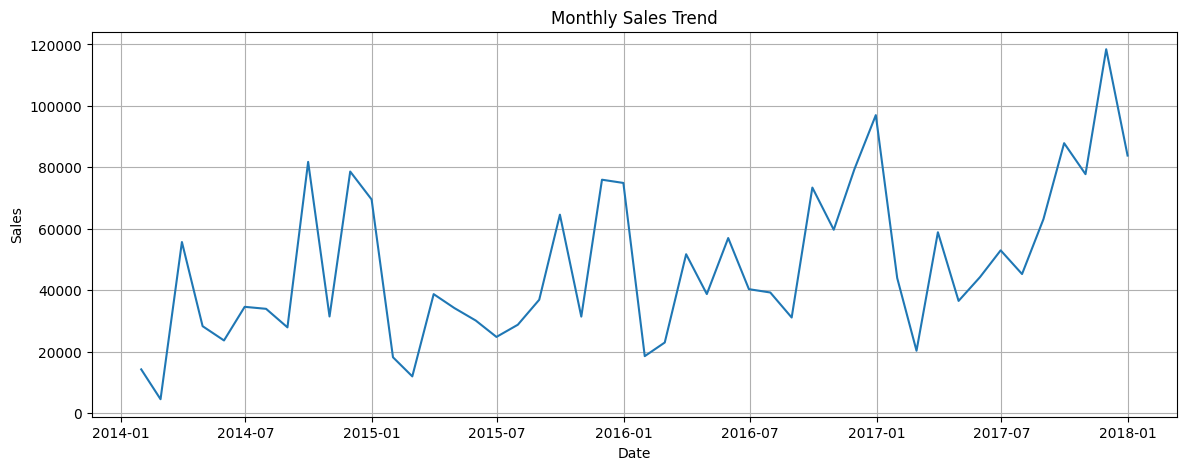

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


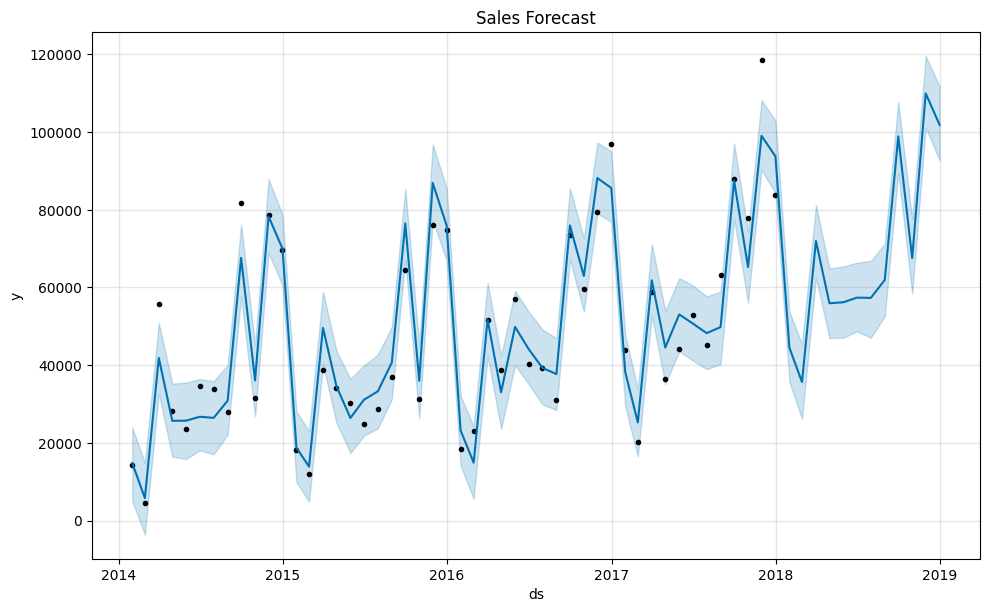

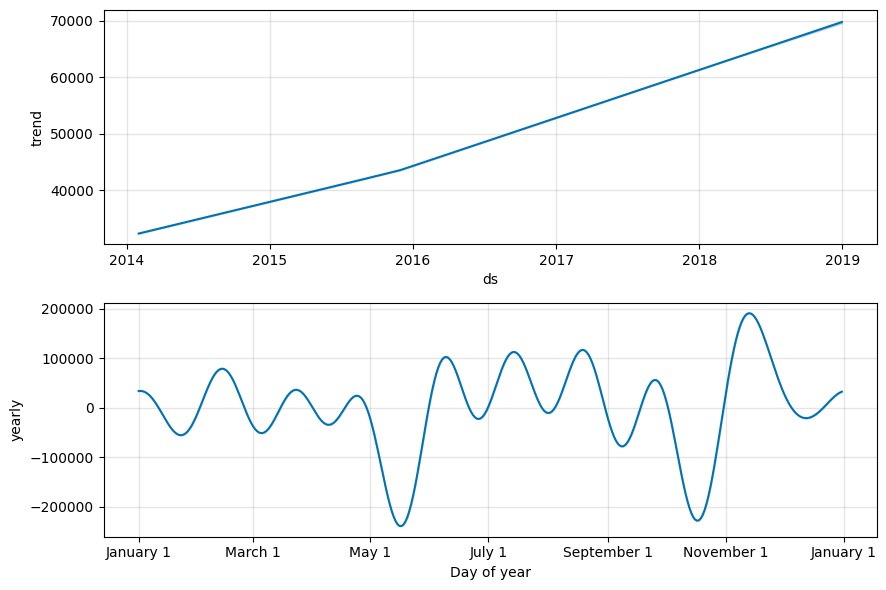

file berhasil disimpan


In [2]:
# install library

!pip install prophet
!pip install plotly


# connect google drive

from google.colab import drive
drive.mount('/content/drive')


# import library

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from prophet import Prophet


# load data

df = pd.read_csv(
    '/content/drive/My Drive/Colab Notebooks/00 My Exercise/01 Ecommerse Insight/Sample - Superstore.csv',
    encoding='latin1'
)

df.head()


# ubah tipe data tanggal

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


# bikin kolom tambahan

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.strftime('%B')


# cek data kosong

df.isnull().sum()


# lihat info data

df.info()


# total sales

total_sales = df['Sales'].sum()
print('Total Sales :', total_sales)


# total profit

total_profit = df['Profit'].sum()
print('Total Profit :', total_profit)


# total order

total_order = df['Order ID'].nunique()
print('Total Order :', total_order)


# sales trend per bulan

monthly_sales = df.groupby(
    pd.Grouper(
        key='Order Date',
        freq='ME'
    )
)['Sales'].sum().reset_index()

monthly_sales.head()


plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales']
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.grid()

plt.show()


# sales by region

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

fig = px.bar(
    region_sales,
    x='Region',
    y='Sales',
    title='Sales by Region'
)

fig.show()


# sales by category

category_sales = df.groupby('Category')['Sales'].sum().reset_index()

fig = px.pie(
    category_sales,
    names='Category',
    values='Sales',
    title='Sales by Category'
)

fig.show()


# top 10 product

top_product = df.groupby('Product Name')['Sales'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .reset_index()

fig = px.bar(
    top_product,
    x='Sales',
    y='Product Name',
    orientation='h',
    title='Top 10 Product'
)

fig.show()


# sales by segment

segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

fig = px.bar(
    segment_sales,
    x='Segment',
    y='Sales',
    title='Sales by Segment'
)

fig.show()


# top state

top_state = df.groupby('State')['Sales'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .reset_index()

fig = px.bar(
    top_state,
    x='State',
    y='Sales',
    title='Top State by Sales'
)

fig.show()


# forecasting

forecast_df = df.groupby(
    pd.Grouper(
        key='Order Date',
        freq='ME'
    )
)['Sales'].sum().reset_index()

forecast_df.columns = ['ds', 'y']

forecast_df.head()


# model prophet

model = Prophet()

model.fit(forecast_df)


# prediksi 12 bulan ke depan

future = model.make_future_dataframe(
    periods=12,
    freq='ME'
)

forecast = model.predict(future)

forecast.head()


# hasil forecast

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)


# visual forecast

model.plot(forecast)

plt.title('Sales Forecast')

plt.show()


# komponen forecast

model.plot_components(forecast)

plt.show()


# save hasil forecast

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '/content/drive/My Drive/Colab Notebooks/00 My Exercise/01 Ecommerse Insight/forecast_result.csv',
    index=False
)


# save clean data

df.to_csv(
    '/content/drive/My Drive/Colab Notebooks/00 My Exercise/01 Ecommerse Insight/clean_data.csv',
    index=False
)


print('file berhasil disimpan')